# YVA DeepL26_Yolo_Vision_Air_Safe-Drone-Landing
**Author:** Pavel MALAGYI, Antoine MAMETZ, ELISA Aerospace

**Last updated:** March 16, 2026

**GitHub:** [Train and Deploy YOLO Models](https://github.com/pavelmalagyi/DeepL_Yolo_Vision_Air_Safe-Drone-Landing)

**Setup de l'environement**

In [6]:
!pip install ultralytics
from ultralytics import YOLO
import gdown
import numpy as np
import os
from google.colab import files
import glob
from IPython.display import Image, display

Vérifier la disponibilité GPU

In [2]:
!nvidia-smi

Mon Mar 16 22:05:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Préparation du dataset**

In [3]:
# Telechargement du dataset
file_id = '1e-1QytSGY3bf9ncFJhpc-X4rif8NvynS'
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, 'dataset2.zip', quiet=False) # Sauvegarde sous 'dataset2.zip'

# Decompression
!unzip -q "dataset2.zip" -d "/content/custom_data/"
print("Dataset pret.")

Downloading...
From (original): https://drive.google.com/uc?id=1e-1QytSGY3bf9ncFJhpc-X4rif8NvynS
From (redirected): https://drive.google.com/uc?id=1e-1QytSGY3bf9ncFJhpc-X4rif8NvynS&confirm=t&uuid=3d16f6b7-53f1-4b51-a7d1-c3e1d4589ecb
To: /content/dataset2.zip
100%|██████████| 112M/112M [00:00<00:00, 146MB/s]


Dataset pret.


**Entraînement (Désactivé par défaut)**

In [4]:
# Variable pour ne pas relancer l'entrainement
LANCER_ENTRAINEMENT = False

# Hyperparamètres
DATASET = "/content/custom_data/dataset2/data.yaml"
EPOCHS = 60
IMAGE_SIZE = 640
BATCH = 16
LR = 0.02
PATIENCE = 15

if LANCER_ENTRAINEMENT:
    print("\nEntraînement 1 : YOLOv8 Nano")
    !yolo detect train data={DATASET} model=yolov8n.pt epochs={EPOCHS} imgsz={IMAGE_SIZE} batch={BATCH} lr0={LR} patience={PATIENCE} name=run_yolov8n

    print("\nEntraînement 2 : YOLO11 Small")
    !yolo detect train data={DATASET} model=yolo11s.pt epochs={EPOCHS} imgsz={IMAGE_SIZE} batch={BATCH} lr0={LR} patience={PATIENCE} name=run_yolo11s

    print("\nEntraînement 3 : YOLO26 Nano")
    !yolo detect train data={DATASET} model=yolo26n.pt epochs={EPOCHS} imgsz={IMAGE_SIZE} batch={BATCH} lr0={LR} patience={PATIENCE} name=run_yolo26n

    print("\nEntraînement 4 : YOLO26 Small")
    !yolo detect train data={DATASET} model=yolo26s.pt epochs={EPOCHS} imgsz={IMAGE_SIZE} batch={BATCH} lr0={LR} patience={PATIENCE} name=run_yolo26s
else:
    print("Mode evaluation active.")


Entraînement 1 : YOLOv8 Nano
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/custom_data/dataset2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.02, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

In [7]:
!mkdir /content/livrable_modeles # dossier pour regrouper tous les modèles et résultats
!cp -r /content/runs/detect/* /content/livrable_modeles/ # copier TOUS les dossiers d'entraînement

print("Création de l'archive ZIP")
!zip -r -q /content/livrable_modeles.zip /content/livrable_modeles/ # archive ZIP

print("Téléchargement (peut prendre du temps)...")
files.download('/content/livrable_modeles.zip') # téléchargement

mkdir: cannot create directory ‘/content/livrable_modeles’: File exists
Création de l'archive ZIP
Téléchargement (peut prendre du temps)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Évaluation Validation et calcul des seuils**

In [8]:
runs = ["run_yolov8n", "run_yolo11s", "run_yolo26n", "run_yolo26s"]
meilleur_map50 = 0.0
chemin_meilleur_modele = ""

for run_name in runs:
    chemin_poids = f"runs/detect/{run_name}/weights/best.pt"

    #Vérifie si le fichier best.pt existe bien pour cet entraînement
    if os.path.exists(chemin_poids):
        print(f"\n Évaluation de {run_name}...")
        modele_temp = YOLO(chemin_poids)

        #évaluation sur le set de validation
        metriques = modele_temp.val(data=DATASET, split="val", verbose=False)
        score_map50 = metriques.box.map50 #score = metriques.box.map sir 50-95

        print(f"-> Score mAP@50 pour {run_name} : {score_map50:.4f}")

        #si score est meilleur, on met à jour la selection
        if score_map50 > meilleur_map50:
            meilleur_map50 = score_map50
            chemin_meilleur_modele = chemin_poids
    else:
        print(f"ERR : Les poids pour {run_name} n'ont pas été trouvés.")

print(f"\n Meilleurs modèle : {chemin_meilleur_modele.split('/')[2]} avec une mAP@50 de {meilleur_map50:.4f}")

# On charge automatiquement le meilleur modèle dans la variable pour la suite du programme
modele_choisi = YOLO(chemin_meilleur_modele)
print("Le meilleur modèle est chargé pour la recherche des seuils.")


 Évaluation de run_yolov8n...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2965.9±1542.9 MB/s, size: 214.5 KB)
val: Scanning /content/custom_data/dataset2/val/labels.cache... 56 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 56/56 7.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.4it/s 1.7s
                   all         56         30      0.935          1      0.995      0.992
Speed: 3.5ms preprocess, 9.6ms inference, 0.0ms loss, 5.1ms postprocess per image
Results saved to /content/runs/detect/val
-> Score mAP@50 pour run_yolov8n : 0.9950

 Évaluation de run_yolo11s...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
va

In [9]:
print("Evaluation sur le set de validation...")
metriques = modele_choisi.val(data="/content/custom_data/dataset2/data.yaml", split="val")
print(f"mAP@50 (Validation) : {metriques.box.map50:.3f}")

# Recherche des seuils
tau_conf_list = [0.5, 0.6, 0.7, 0.8, 0.85, 0.90]
tau_area_list = [0.01, 0.03, 0.05, 0.08]

meilleur_score = 0
meilleur_tau_conf = 0.80
meilleur_tau_area = 0.05

for conf in tau_conf_list:
    for area in tau_area_list:
        penalite = 1.0 if conf >= 0.80 else 0.1
        score_securite = (conf * 0.7 + area * 0.3) * penalite

        if score_securite > meilleur_score:
            meilleur_score = score_securite
            meilleur_tau_conf = conf
            meilleur_tau_area = area

print(f"Seuils retenus : conf = {meilleur_tau_conf}, area = {meilleur_tau_area}")

Evaluation sur le set de validation...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2853.0±2167.5 MB/s, size: 142.9 KB)
val: Scanning /content/custom_data/dataset2/val/labels.cache... 56 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 56/56 15.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2it/s 3.5s
                   all         56         30      0.935          1      0.995      0.992
Speed: 16.3ms preprocess, 4.9ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /content/runs/detect/val5
mAP@50 (Validation) : 0.995
Seuils retenus : conf = 0.9, area = 0.08


In [10]:
!yolo detect predict model={chemin_meilleur_modele} source=custom_data/dataset2/val/images save=True

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/56 /content/custom_data/dataset2/val/images/0622f7b9-im0105.jpg: 640x640 (no detections), 8.2ms
image 2/56 /content/custom_data/dataset2/val/images/1375c813-im0169.jpg: 640x640 (no detections), 6.2ms
image 3/56 /content/custom_data/dataset2/val/images/19a07b8b-IMG_1452.jpg: 640x480 1 Landing_pad, 42.8ms
image 4/56 /content/custom_data/dataset2/val/images/23a1f72a-PXL_20230323_153239335_jpg.rf.7aa402054d4b07a46767c273ecd0e73e.jpg: 640x640 (no detections), 6.3ms
image 5/56 /content/custom_data/dataset2/val/images/249b607b-PXL_20230323_152743256_jpg.rf.477d6c6a9ec9c876156be66f15963b25.jpg: 640x640 1 Landing_pad, 5.3ms
image 6/56 /content/custom_data/dataset2/val/images/2eac7485-PXL_20230323_153407848_jpg.rf.a640f864c4aad0582c179c79f0174ed0.jpg: 640x640 1 Landing_pad, 5.5ms
image 7/56 /content/custom_data/dataset2/val/im

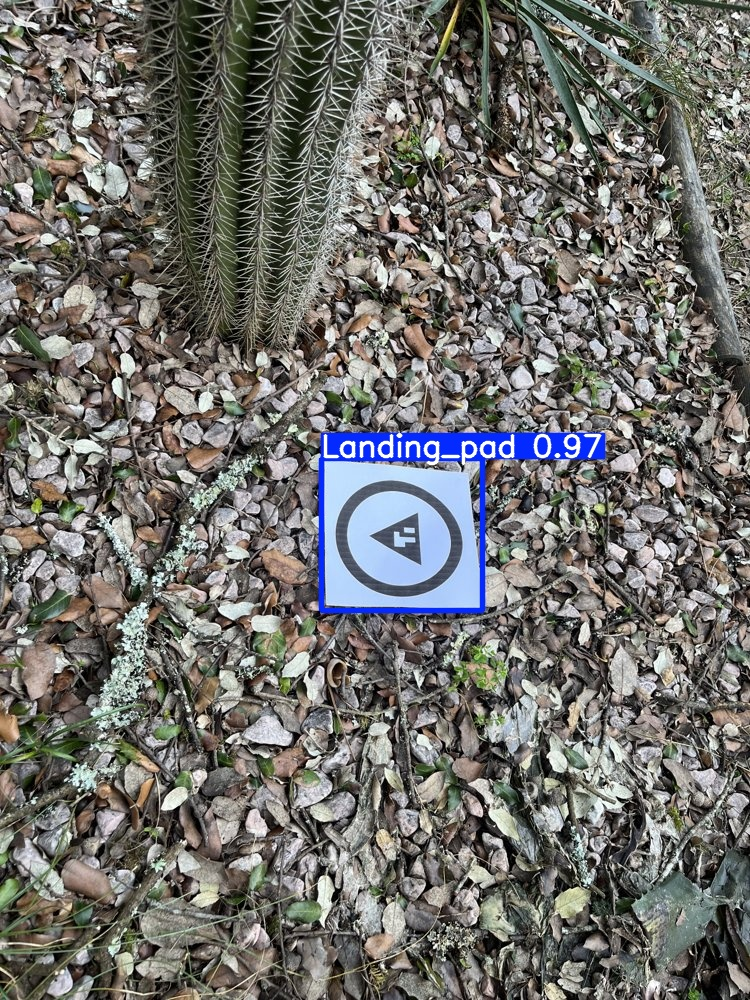

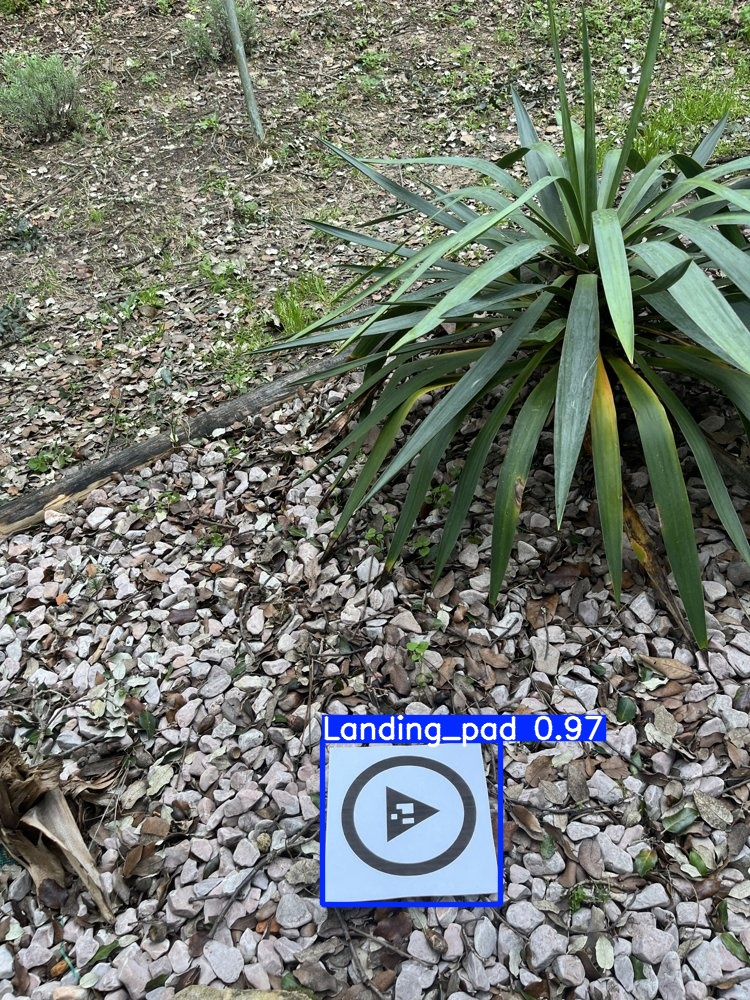

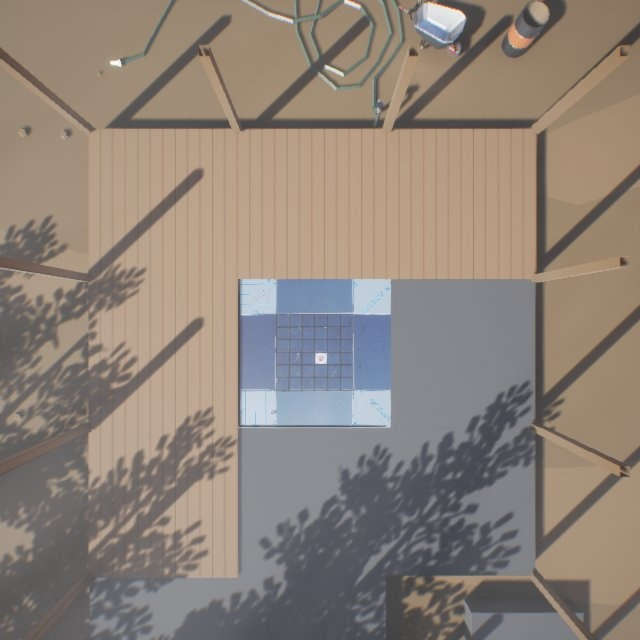

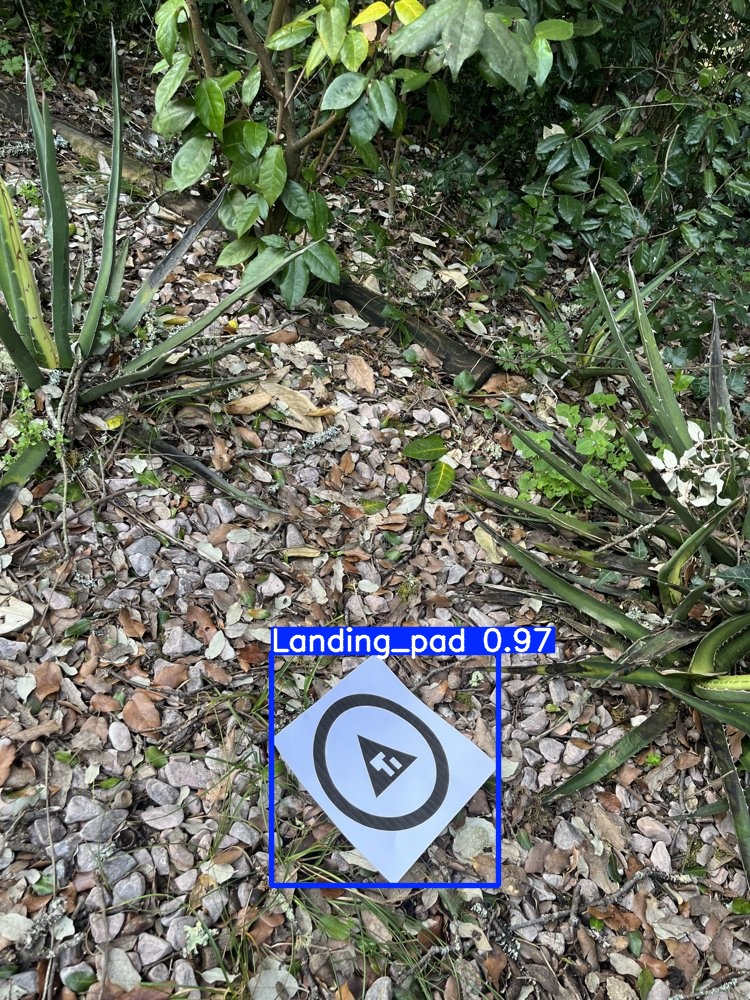

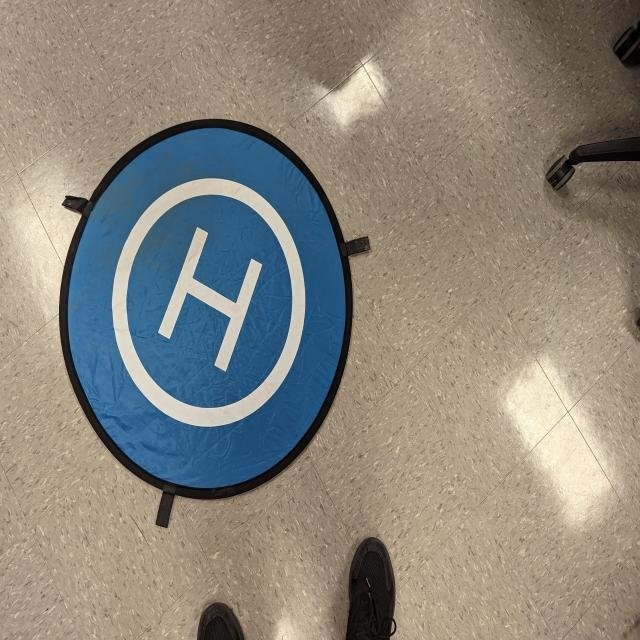

In [11]:
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:5]:
  display(Image(filename=image_path, height=400))
  print('\n')

**Fonction de décision**

In [12]:
def check_landing_safety(confidence, box_w_norm, box_h_norm, tau_conf=meilleur_tau_conf, tau_area=meilleur_tau_area):
    """
    Algorithme de decision base sur les donnees de validation.
    """
    area_ratio = box_w_norm * box_h_norm

    if confidence >= tau_conf and area_ratio >= tau_area:
        decision = "safe"
    else:
        decision = "not_safe"

    return decision, area_ratio

# Simulation de test
resultat, surface = check_landing_safety(confidence=0.85, box_w_norm=0.30, box_h_norm=0.20)
print(f"Surface detectee : {surface * 100:.1f}%")
print(f"Decision du systeme : {resultat}")

Surface detectee : 6.0%
Decision du systeme : not_safe


**Évaluation finale (Validation) **

In [13]:
print("Evaluation finale des performances sur le set de validation...")

# Utilisation du split val
metriques_finales = modele_choisi.val(data="/content/custom_data/dataset2/data.yaml", split="val")

print("\nResultats definitifs (Validation set)")
print(f"mAP@50 : {metriques_finales.box.map50:.3f}")

Evaluation finale des performances sur le set de validation...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1944.6±866.7 MB/s, size: 88.2 KB)
val: Scanning /content/custom_data/dataset2/val/labels.cache... 56 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 56/56 4.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.0it/s 2.0s
                   all         56         30      0.935          1      0.995      0.992
Speed: 9.9ms preprocess, 6.3ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detect/val6

Resultats definitifs (Validation set)
mAP@50 : 0.995


**Export visuel des prédictions (Validation)**

In [15]:
from ultralytics import YOLO

# 1. Evaluation du modele 8n et creation des planches
print("Evaluation 8n...")
modele_8n = YOLO("/content/runs/detect/run_yolov8n/weights/best.pt")
# L'argument name definit le dossier de sortie
modele_8n.val(data="/content/custom_data/dataset2/data.yaml", split="val", name="eval_8n")

# 2. Evaluation du modele 26n et creation des planches
print("\nEvaluation 26n...")
modele_26n = YOLO("/content/runs/detect/run_yolo26n/weights/best.pt")
modele_26n.val(data="/content/custom_data/dataset2/data.yaml", split="val", name="eval_26n")

print("\nTermine. Les dossiers eval_8n et eval_26n sont crees.")

Evaluation 8n...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1610.4±325.8 MB/s, size: 152.6 KB)
val: Scanning /content/custom_data/dataset2/val/labels.cache... 56 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 56/56 14.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.9it/s 2.1s
                   all         56         30      0.935          1      0.995      0.992
Speed: 11.8ms preprocess, 6.1ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detect/eval_8n

Evaluation 26n...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2925.9±2037.5 MB

In [16]:
# On retire l'option -j pour garder les dossiers et eviter les doublons de noms
print("Compression des planches de resultats...")
!zip -r planches_validation.zip runs/detect/eval_8n/val_batch*_pred.jpg runs/detect/eval_26n/val_batch*_pred.jpg

# Telechargement du fichier genere
files.download('planches_validation.zip')
print("Le fichier planches_validation.zip est pret.")

Compression des planches de resultats...
  adding: runs/detect/eval_8n/val_batch0_pred.jpg (deflated 9%)
  adding: runs/detect/eval_8n/val_batch1_pred.jpg (deflated 8%)
  adding: runs/detect/eval_8n/val_batch2_pred.jpg (deflated 2%)
  adding: runs/detect/eval_26n/val_batch0_pred.jpg (deflated 9%)
  adding: runs/detect/eval_26n/val_batch1_pred.jpg (deflated 8%)
  adding: runs/detect/eval_26n/val_batch2_pred.jpg (deflated 2%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Le fichier planches_validation.zip est pret.


**Evaluation sur le set de test**

In [18]:
import torch
# Lancement de l'évaluation finale et définitive sur le dossier test
print("Évaluation finale en cours sur les données de test...")

# On utilise split="test" pour s'assurer qu'il prend le bon dossier
metriques_test = modele_choisi.val(data="/content/custom_data/dataset2/data.yaml", split="test")

# Affichage des métriques définitives
print("\nRésultats définitifs YOLOV8n(test set)")
print(f"mAP@50 (Test) : {metriques_test.box.map50:.4f}")
print(f"mAP50-95 (Test) : {metriques_test.box.map:.4f}")
print(f"Precision (Test) : {metriques_test.box.mp:.4f}")
print(f"Recall (Test) : {metriques_test.box.mr:.4f}")
if torch.cuda.is_available():
    memoire_max = torch.cuda.max_memory_allocated() / (1024 ** 2)
    print(f"GPU Memory Peak : {memoire_max:.2f} MB")
else:
    print("GPU Memory : N/A (Évaluation CPU)")

Évaluation finale en cours sur les données de test...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 1.6±3.6 ms, read: 1858.8±298.3 MB/s, size: 261.7 KB)
val: Scanning /content/custom_data/dataset2/test/labels.cache... 53 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 53/53 10.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0it/s 3.8s
                   all         53         55      0.998      0.945      0.978      0.954
Speed: 15.2ms preprocess, 7.6ms inference, 0.0ms loss, 5.8ms postprocess per image
Results saved to /content/runs/detect/val8

Résultats définitifs YOLOV8n(test set)
mAP@50 (Test) : 0.9784
mAP50-95 (Test) : 0.9536
Precision (Test) : 0.9983
Recall (Test) : 0.9455
GPU Memory Peak : 951.84 MB



 Les graphiques YOLO V8n ont été générés dans : /content/runs/detect/val8

 Matrice de Confusion (Test Set) :


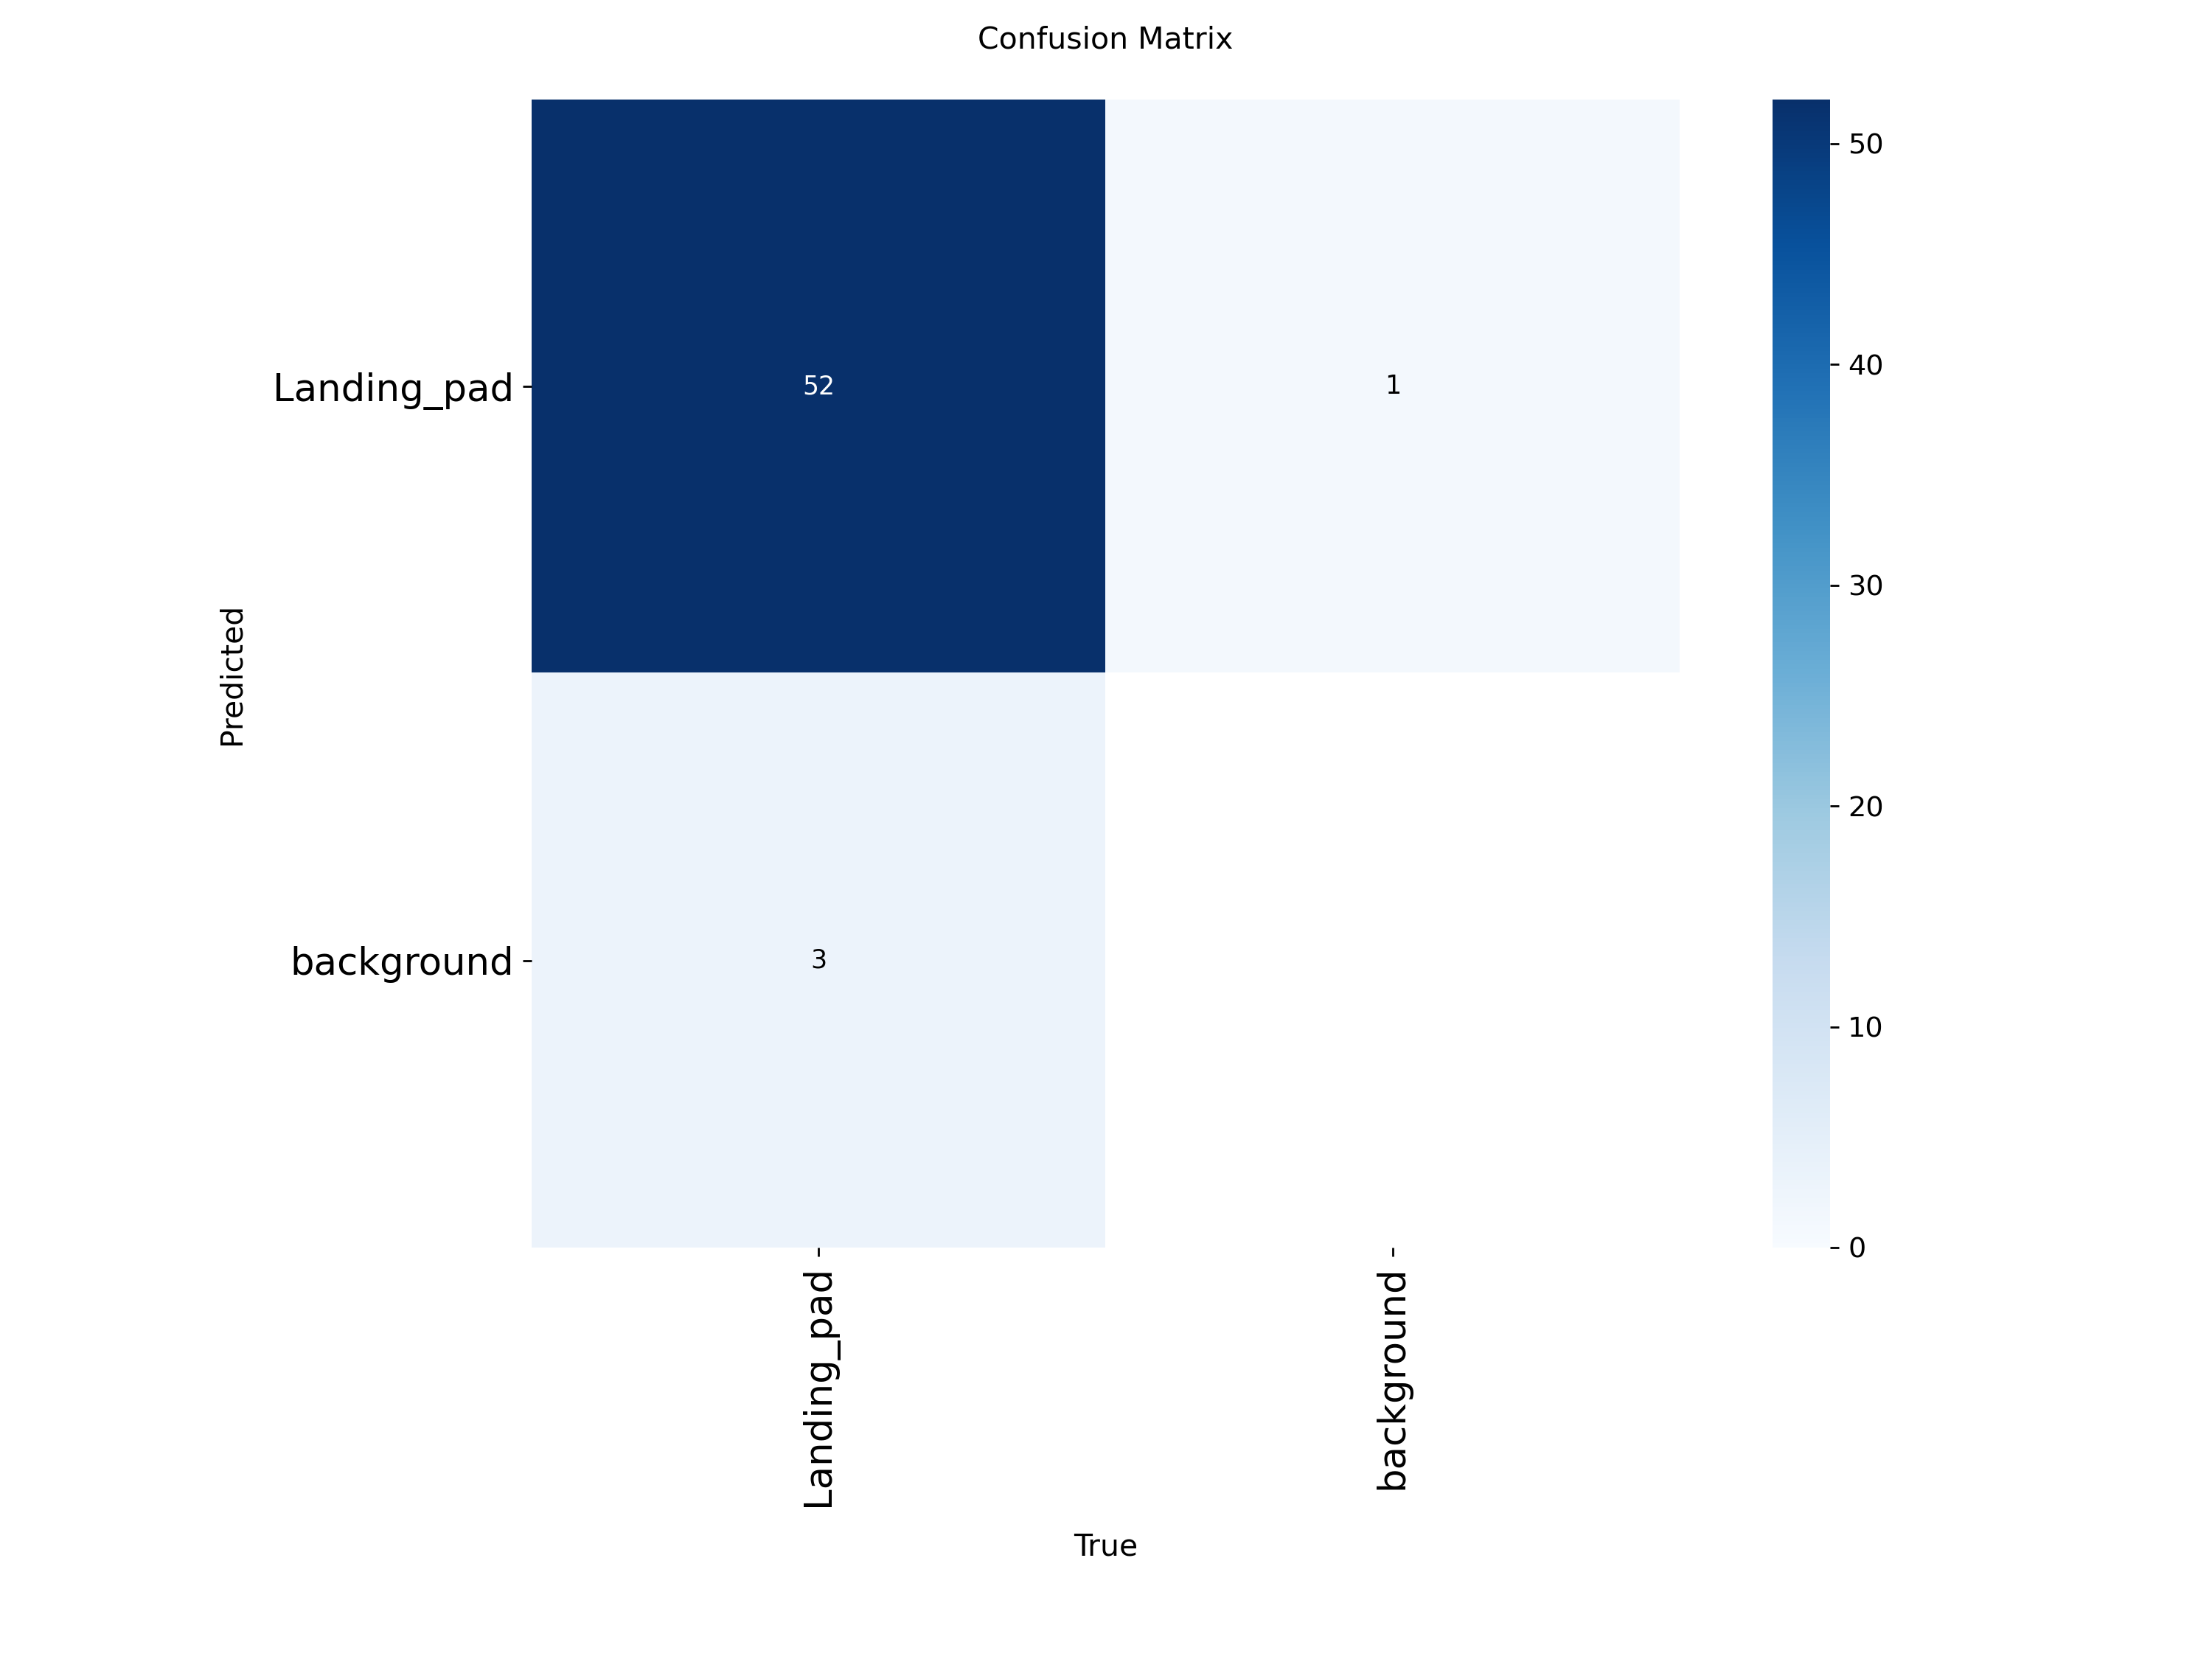


 Aperçu des prédictions (Test Set) :


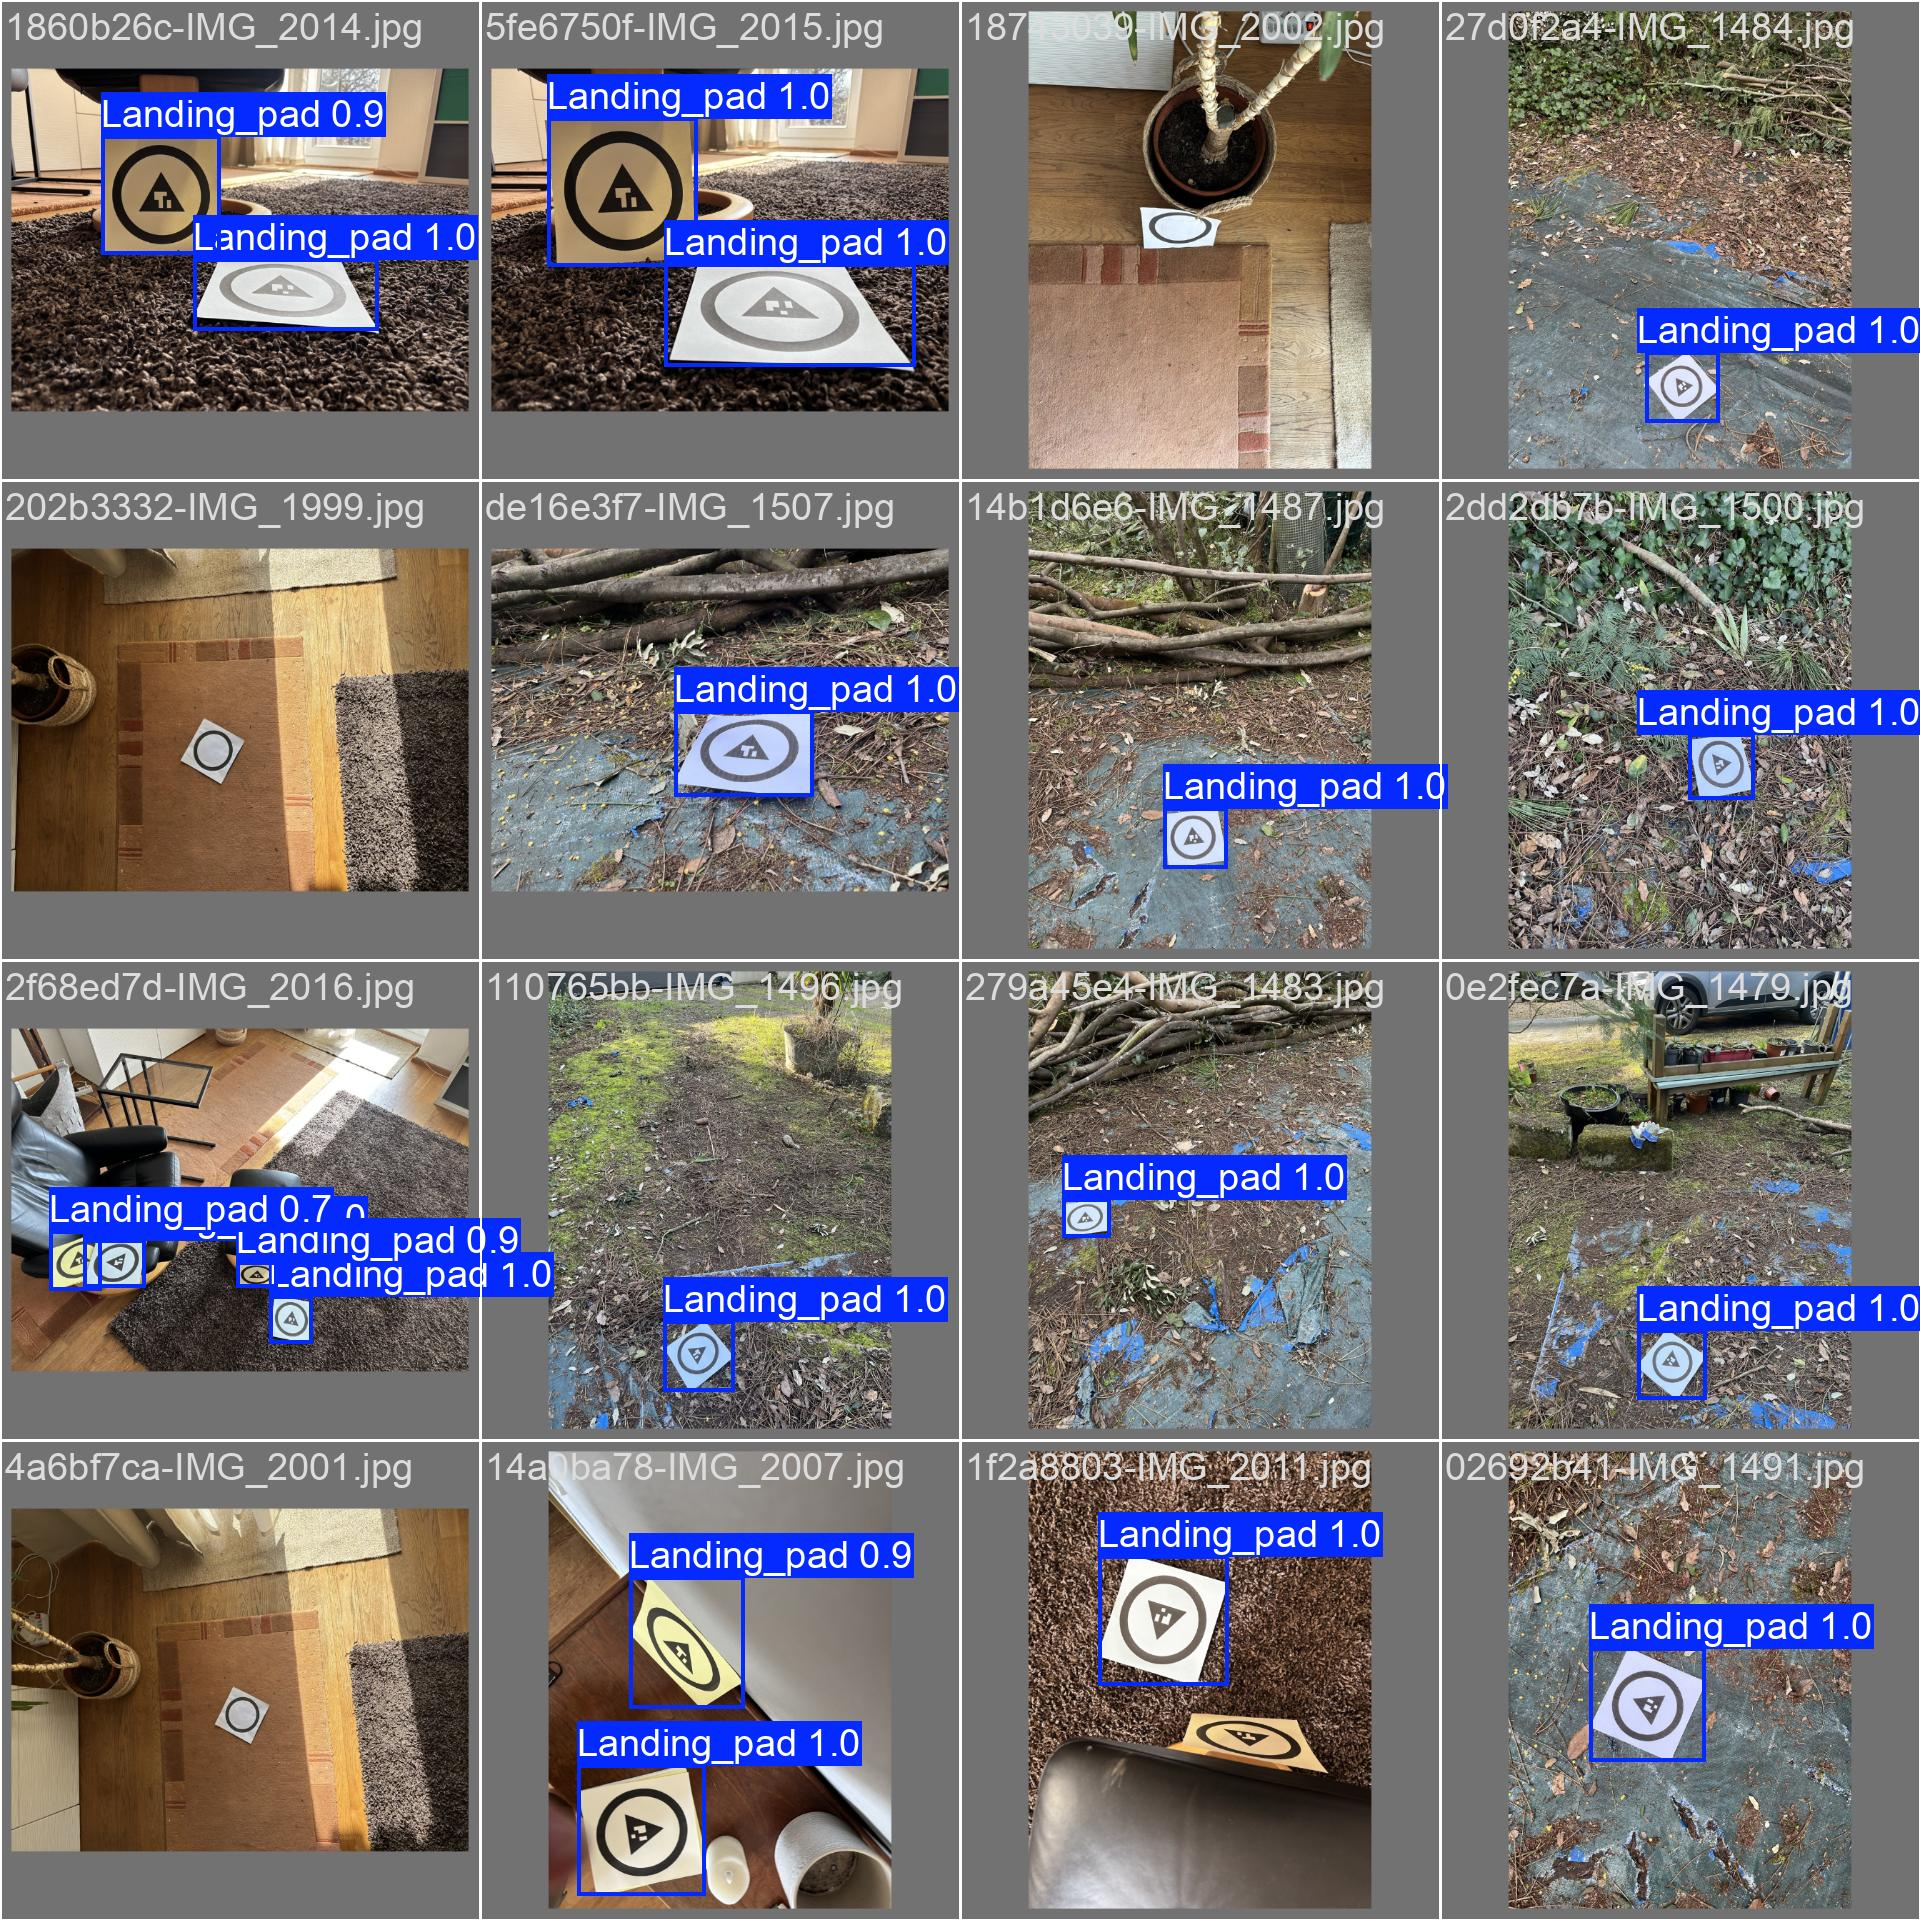

In [19]:
print(f"\n Les graphiques YOLO V8n ont été générés dans : {metriques_test.save_dir}")

chemin_matrice = os.path.join(metriques_test.save_dir, "confusion_matrix.png") # confusion_matrix_normalized.png
chemin_resultats = os.path.join(metriques_test.save_dir, "val_batch0_pred.jpg")

if os.path.exists(chemin_matrice):
    print("\n Matrice de Confusion (Test Set) :")
    display(Image(filename=chemin_matrice, width=800))
else:
    print("\n Fichier de matrice de confusion introuvable.")

if os.path.exists(chemin_resultats):
    print("\n Aperçu des prédictions (Test Set) :")
    display(Image(filename=chemin_resultats, width=1000))
else:
    print("\n Fichier de résultats visuels introuvable.")